In [4]:
from datetime import datetime, timedelta, timezone

base = "https://thredds.met.no/thredds/dodsC/ww3_4km_latest_files/ww3_{stamp}.nc"

now = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)
cycle_hour = (now.hour // 6) * 6
start = now.replace(hour=cycle_hour)

latest_url = None
for k in range(0, 80):  # checks up to ~20 days back (6-hour cycles)
    run_time = start - timedelta(hours=6 * k)
    candidate = base.format(stamp=run_time.strftime("%Y%m%dT%HZ"))
    print(f"Testing URL: {candidate}")
    try:
        test_ds = xr.open_dataset(candidate)
        test_ds.close()
        latest_url = candidate
        break
    except Exception:
        continue

if latest_url is None:
    print("No working WW3 OPeNDAP link found in the search window.")
else:
    url = latest_url  # overwrite existing url
    print("Most recent working link:", url)

# Station definitions (set once, reused in map + time series)
STATIONS = [
    {"name": "Station 1", "lat": 58.5, "lon": 10.5, "color": "tab:orange"},
    {"name": "Station 2", "lat": 59.2, "lon": 10.65, "color": "tab:blue"},
    {"name": "Station 3", "lat": 58.0, "lon":  9.0, "color": "tab:green"},
]

Testing URL: https://thredds.met.no/thredds/dodsC/ww3_4km_latest_files/ww3_20260303T12Z.nc
Testing URL: https://thredds.met.no/thredds/dodsC/ww3_4km_latest_files/ww3_20260303T06Z.nc
Most recent working link: https://thredds.met.no/thredds/dodsC/ww3_4km_latest_files/ww3_20260303T06Z.nc


In [5]:
import xarray as xr

# url = "https://thredds.met.no/thredds/dodsC/ww3_4km_latest_files/ww3_20260302T06Z.nc"

# Open remote NetCDF (OPeNDAP) dataset
ds = xr.open_dataset(url)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Read variables
phs1 = ds["phs1"]
pdir1 = ds["pdir1"]

# # Skagerrak bounds (approx.)
# lon_min, lon_max = 7.0, 12.0
# lat_min, lat_max = 55.0, 59.5

# North Sea bounds (approx.)
lon_min, lon_max = 1.0, 12.0
lat_min, lat_max = 51.0, 59.5

# Mask to bounds using 2D lon/lat coordinates
mask = (
    (ds["longitude"] >= lon_min) & (ds["longitude"] <= lon_max) &
    (ds["latitude"] >= lat_min) & (ds["latitude"] <= lat_max)
)

phs1_skag = phs1.where(mask, drop=True)
pdir1_skag = pdir1.where(mask, drop=True)

# Fixed color scale across all times
vmin = float(np.nanmin(phs1_skag.values))
vmax = float(np.nanmax(phs1_skag.values))

# Fixed iso levels across all times (0.25 m interval)
level_start = np.floor(vmin / 0.25) * 0.25
level_end = np.ceil(vmax / 0.25) * 0.25
levels = np.arange(level_start, level_end + 0.25, 0.25)
if levels.size < 2:
    levels = np.array([level_start, level_start + 0.25])

# Direction vectors settings
step = 6

# Plot every time step with same style and color scale
for i, t in enumerate(phs1_skag.time.values):
    phs1_t = phs1_skag.isel(time=i)
    pdir1_t = pdir1_skag.isel(time=i)
    lon_t = ds["longitude"].sel(rlat=phs1_t.rlat, rlon=phs1_t.rlon)
    lat_t = ds["latitude"].sel(rlat=phs1_t.rlat, rlon=phs1_t.rlon)

    # Ensure x/y are finite for pcolormesh, mask data where they are not
    valid_xy = np.isfinite(lon_t.values) & np.isfinite(lat_t.values)
    lon_plot = np.where(valid_xy, lon_t.values, 0.0)
    lat_plot = np.where(valid_xy, lat_t.values, 0.0)
    phs_plot = np.where(valid_xy, phs1_t.values, np.nan)

    fig = plt.figure(figsize=(9, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    mesh = ax.pcolormesh(
        lon_plot,
        lat_plot,
        phs_plot,
        transform=ccrs.PlateCarree(),
        cmap="magma",
        shading="auto",
        vmin=vmin,
        vmax=vmax
    )

    cs = ax.contour(
        lon_plot,
        lat_plot,
        phs_plot,
        levels=levels,
        colors="deepskyblue",
        linewidths=0.8,
        alpha=0.9,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f", colors="deepskyblue")

    lon_q = lon_t[::step, ::step]
    lat_q = lat_t[::step, ::step]
    pdir_q = pdir1_t[::step, ::step]

    valid = np.isfinite(lon_q.values) & np.isfinite(lat_q.values) & np.isfinite(pdir_q.values)
    theta = np.deg2rad(pdir_q.values[valid])
    u = -np.sin(theta)
    v = -np.cos(theta)

    ax.quiver(
        lon_q.values[valid],
        lat_q.values[valid],
        u,
        v,
        transform=ccrs.PlateCarree(),
        color="darkgrey",
        scale=45,
        width=0.002,
        alpha=0.8
    )

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
    gl.top_labels = False
    gl.right_labels = False

    for station in STATIONS:
        ax.scatter(
            station["lon"],
            station["lat"],
            color=station["color"],
            s=45,
            edgecolor="black",
            linewidth=0.5,
            transform=ccrs.PlateCarree(),
            zorder=6,
            label=station["name"]
        )
    ax.legend(loc="lower right", fontsize=8)

    plt.colorbar(mesh, ax=ax, label="phs1 (m)", shrink=0.8, orientation="horizontal", pad=0.08)
    plt.title(f'phs1 with pdir1 vectors in Skagerrak at {str(t)[:16]}')
    plt.tight_layout()
    ii = i + 1
    print(f"Saving figure {ii:03d} for time {str(t)[:16]}...")
    plt.savefig(f"surf_skagerrak_{ii:03d}.png", dpi=200, bbox_inches="tight")
    # plt.show()
    # Close the figure to free memory
    plt.close(fig)

Saving figure 001 for time 2026-03-03T00:00...
Saving figure 002 for time 2026-03-03T01:00...
Saving figure 003 for time 2026-03-03T02:00...
Saving figure 004 for time 2026-03-03T03:00...
Saving figure 005 for time 2026-03-03T04:00...
Saving figure 006 for time 2026-03-03T05:00...
Saving figure 007 for time 2026-03-03T06:00...
Saving figure 008 for time 2026-03-03T07:00...
Saving figure 009 for time 2026-03-03T08:00...
Saving figure 010 for time 2026-03-03T09:00...
Saving figure 011 for time 2026-03-03T10:00...
Saving figure 012 for time 2026-03-03T11:00...
Saving figure 013 for time 2026-03-03T12:00...
Saving figure 014 for time 2026-03-03T13:00...
Saving figure 015 for time 2026-03-03T14:00...
Saving figure 016 for time 2026-03-03T15:00...
Saving figure 017 for time 2026-03-03T16:00...
Saving figure 018 for time 2026-03-03T17:00...
Saving figure 019 for time 2026-03-03T18:00...
Saving figure 020 for time 2026-03-03T19:00...
Saving figure 021 for time 2026-03-03T20:00...
Saving figure

Station 1 requested position: lat=58.5, lon=10.5
Station 1 nearest grid point: lat=58.5095, lon=10.4959
Station 2 requested position: lat=59.2, lon=10.65
Station 2 nearest grid point: lat=59.1875, lon=10.6222
Station 3 requested position: lat=58.0, lon=9.0
Station 3 nearest grid point: lat=58.0009, lon=8.9900


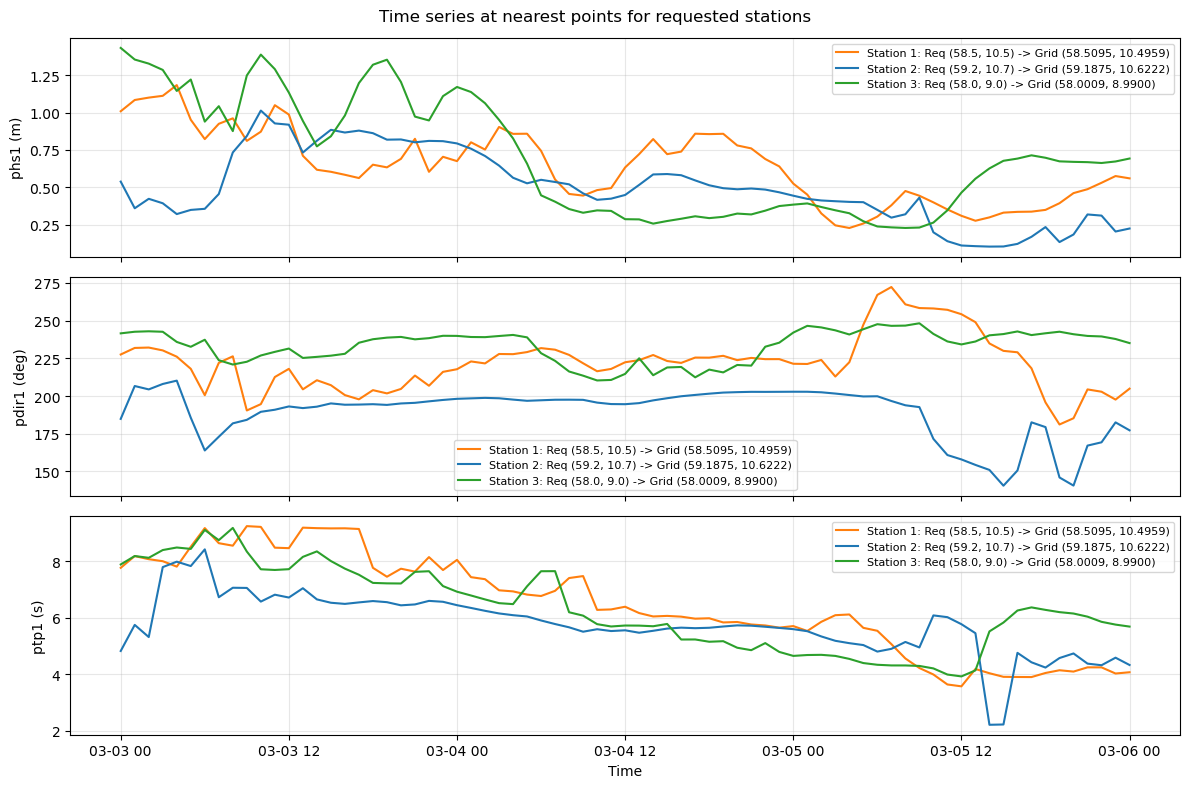

In [7]:
# Read additional variable
ptp1 = ds["ptp1"]

# Find nearest grid cells from 2D latitude/longitude
lat2d = ds["latitude"].values
lon2d = ds["longitude"].values

station_data = []
for station in STATIONS:
    target_lat = station["lat"]
    target_lon = station["lon"]
    dist2 = (lat2d - target_lat) ** 2 + (lon2d - target_lon) ** 2
    dist2[~np.isfinite(dist2)] = np.inf
    iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)

    nearest_lat = float(ds["latitude"].isel(rlat=iy, rlon=ix).values)
    nearest_lon = float(ds["longitude"].isel(rlat=iy, rlon=ix).values)

    station_data.append({
        "requested": (target_lat, target_lon),
        "nearest": (nearest_lat, nearest_lon),
        "name": station["name"],
        "color": station["color"],
        "phs1": phs1.isel(rlat=iy, rlon=ix),
        "pdir1": pdir1.isel(rlat=iy, rlon=ix),
        "ptp1": ptp1.isel(rlat=iy, rlon=ix)
    })

    print(f"{station['name']} requested position: lat={target_lat}, lon={target_lon}")
    print(f"{station['name']} nearest grid point: lat={nearest_lat:.4f}, lon={nearest_lon:.4f}")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axis_specs = [
    ("phs1", "phs1 (m)"),
    ("pdir1", "pdir1 (deg)"),
    ("ptp1", "ptp1 (s)")
]

for ax, (var_name, y_label) in zip(axes, axis_specs):
    for station in station_data:
        req_lat, req_lon = station["requested"]
        near_lat, near_lon = station["nearest"]
        ts = station[var_name]
        ax.plot(
            ts.time.values,
            ts.values,
            color=station["color"],
            label=f"{station['name']}: Req ({req_lat:.1f}, {req_lon:.1f}) -> Grid ({near_lat:.4f}, {near_lon:.4f})"
        )
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

axes[2].set_xlabel("Time")

plt.suptitle("Time series at nearest points for requested stations")
plt.tight_layout()
# plt.show()

# Save time series plot for both stations
plt.savefig("time_series_stations.png", dpi=200, bbox_inches="tight")

In [11]:
import glob
import subprocess

files = sorted(glob.glob("surf_*.png") + glob.glob("time_series*.png"))

if not files:
    print("No matching PNG files found.")
else:
    dest = "projects.met.no:/home/nilsmk/public_html/surf/"
    cmd = ["scp", *files, dest]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
    print(f"Uploaded {len(files)} file(s).")

Running: scp surf_skagerrak_001.png surf_skagerrak_002.png surf_skagerrak_003.png surf_skagerrak_004.png surf_skagerrak_005.png surf_skagerrak_006.png surf_skagerrak_007.png surf_skagerrak_008.png surf_skagerrak_009.png surf_skagerrak_010.png surf_skagerrak_011.png surf_skagerrak_012.png surf_skagerrak_013.png surf_skagerrak_014.png surf_skagerrak_015.png surf_skagerrak_016.png surf_skagerrak_017.png surf_skagerrak_018.png surf_skagerrak_019.png surf_skagerrak_020.png surf_skagerrak_021.png surf_skagerrak_022.png surf_skagerrak_023.png surf_skagerrak_024.png surf_skagerrak_025.png surf_skagerrak_026.png surf_skagerrak_027.png surf_skagerrak_028.png surf_skagerrak_029.png surf_skagerrak_030.png surf_skagerrak_031.png surf_skagerrak_032.png surf_skagerrak_033.png surf_skagerrak_034.png surf_skagerrak_035.png surf_skagerrak_036.png surf_skagerrak_037.png surf_skagerrak_038.png surf_skagerrak_039.png surf_skagerrak_040.png surf_skagerrak_041.png surf_skagerrak_042.png surf_skagerrak_043.pn